# 🏦 Bank Customer Churn — Full Analysis Pipeline
**Sections:** Data Loading → Cleaning → Feature Engineering → EDA → Machine Learning → Power BI Export

---

## 1. Install & Import Libraries

In [1]:
# Install dependencies (run once)
# !pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve
)

import os
os.makedirs('outputs', exist_ok=True)

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


## 2. Load Data

In [2]:


df = pd.read_csv(r'C:\Users\Admin\Documents\Rinsha\Data Analysis Project\Bank Churn\Data\Bank_Churn.csv')
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nNull counts:\n{df.isnull().sum()}")
df.head()

Shape: (10000, 13)

Columns: ['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Null counts:
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# Basic statistics
df.describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
CustomerId,1.569094e+07,71936.186123,15565701.00,15815690.00
CreditScore,6.505288e+02,96.653299,350.00,850.00
Age,3.892180e+01,10.487806,18.00,92.00
Tenure,5.012800e+00,2.892174,0.00,10.00
Balance,7.648589e+04,62397.405202,0.00,250898.09
NumOfProducts,1.530200e+00,0.581654,1.00,4.00
HasCrCard,7.055000e-01,0.455840,0.00,1.00
IsActiveMember,5.151000e-01,0.499797,0.00,1.00
EstimatedSalary,1.000902e+05,57510.492818,11.58,199992.48
Exited,2.037000e-01,0.402769,0.00,1.00


In [4]:
# Target distribution
print("Churn Distribution:")
print(df['Exited'].value_counts())
print(f"\nChurn Rate: {df['Exited'].mean():.2%}")

Churn Distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64

Churn Rate: 20.37%


## 3. Data Cleaning

In [5]:
# Drop non-analytical identifier columns
df.drop(columns=['CustomerId', 'Surname'], inplace=True)

# Remove duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Duplicates removed: {before - len(df)}")

# Clamp domain-illegal outliers
df['CreditScore'] = df['CreditScore'].clip(300, 850)
df['Age']         = df['Age'].clip(18, 100)

# Validate binary flags
for col in ['HasCrCard', 'IsActiveMember', 'Exited']:
    assert df[col].isin([0, 1]).all(), f"{col} has non-binary values"
    print(f"  ✅ {col} — valid binary")

print(f"\nClean shape: {df.shape}")

Duplicates removed: 0
  ✅ HasCrCard — valid binary
  ✅ IsActiveMember — valid binary
  ✅ Exited — valid binary

Clean shape: (10000, 11)


## 4. Feature Engineering

In [6]:
# Ratio features
df['BalanceToSalary'] = df['Balance'] / (df['EstimatedSalary'] + 1)
df['ProductsPerYear'] = df['NumOfProducts'] / (df['Tenure'] + 1)

# Age bins
df['AgeGroup'] = pd.cut(
    df['Age'], bins=[17, 30, 45, 60, 100],
    labels=['18-30', '31-45', '46-60', '60+']
)

# Credit score bands
df['CreditScoreBand'] = pd.cut(
    df['CreditScore'],
    bins=[299, 579, 669, 739, 799, 850],
    labels=['Poor', 'Fair', 'Good', 'VeryGood', 'Exceptional']
)

# Behaviour flags
df['IsZeroBalance']   = (df['Balance'] == 0).astype(int)
df['EngagementScore'] = df['IsActiveMember'] + df['HasCrCard'] + df['NumOfProducts']

print("New features added:")
for f in ['BalanceToSalary','ProductsPerYear','AgeGroup',
          'CreditScoreBand','IsZeroBalance','EngagementScore']:
    print(f"  ✅ {f}")
print(f"\nFinal shape: {df.shape}")

New features added:
  ✅ BalanceToSalary
  ✅ ProductsPerYear
  ✅ AgeGroup
  ✅ CreditScoreBand
  ✅ IsZeroBalance
  ✅ EngagementScore

Final shape: (10000, 17)


In [7]:
df[['BalanceToSalary','ProductsPerYear','IsZeroBalance','EngagementScore']].describe()

,BalanceToSalary,ProductsPerYear,IsZeroBalance,EngagementScore
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,3.790150,0.367173,0.361700,2.750800
std,100.055758,0.337760,0.480517,0.893185
min,0.000000,0.090909,0.000000,1.000000
25%,0.000000,0.166667,0.000000,2.000000
50%,0.746998,0.250000,0.000000,3.000000
75%,1.514002,0.500000,1.000000,3.000000
max,9770.883148,3.000000,1.000000,6.000000


## 5. Exploratory Data Analysis (EDA)

In [8]:
# ── Dark-theme helper ─────────────────────────────────────────
BLUE, RED = '#3498db', '#e74c3c'

def dark_ax(ax, title=''):
    ax.set_facecolor('#1a1d27')
    ax.tick_params(colors='#cccccc', labelsize=9)
    ax.xaxis.label.set_color('#cccccc')
    ax.yaxis.label.set_color('#cccccc')
    for sp in ax.spines.values():
        sp.set_edgecolor('#333344')
    if title:
        ax.set_title(title, color='#ffffff', fontsize=11, pad=8)

print("Helper function defined ✅")

Helper function defined ✅


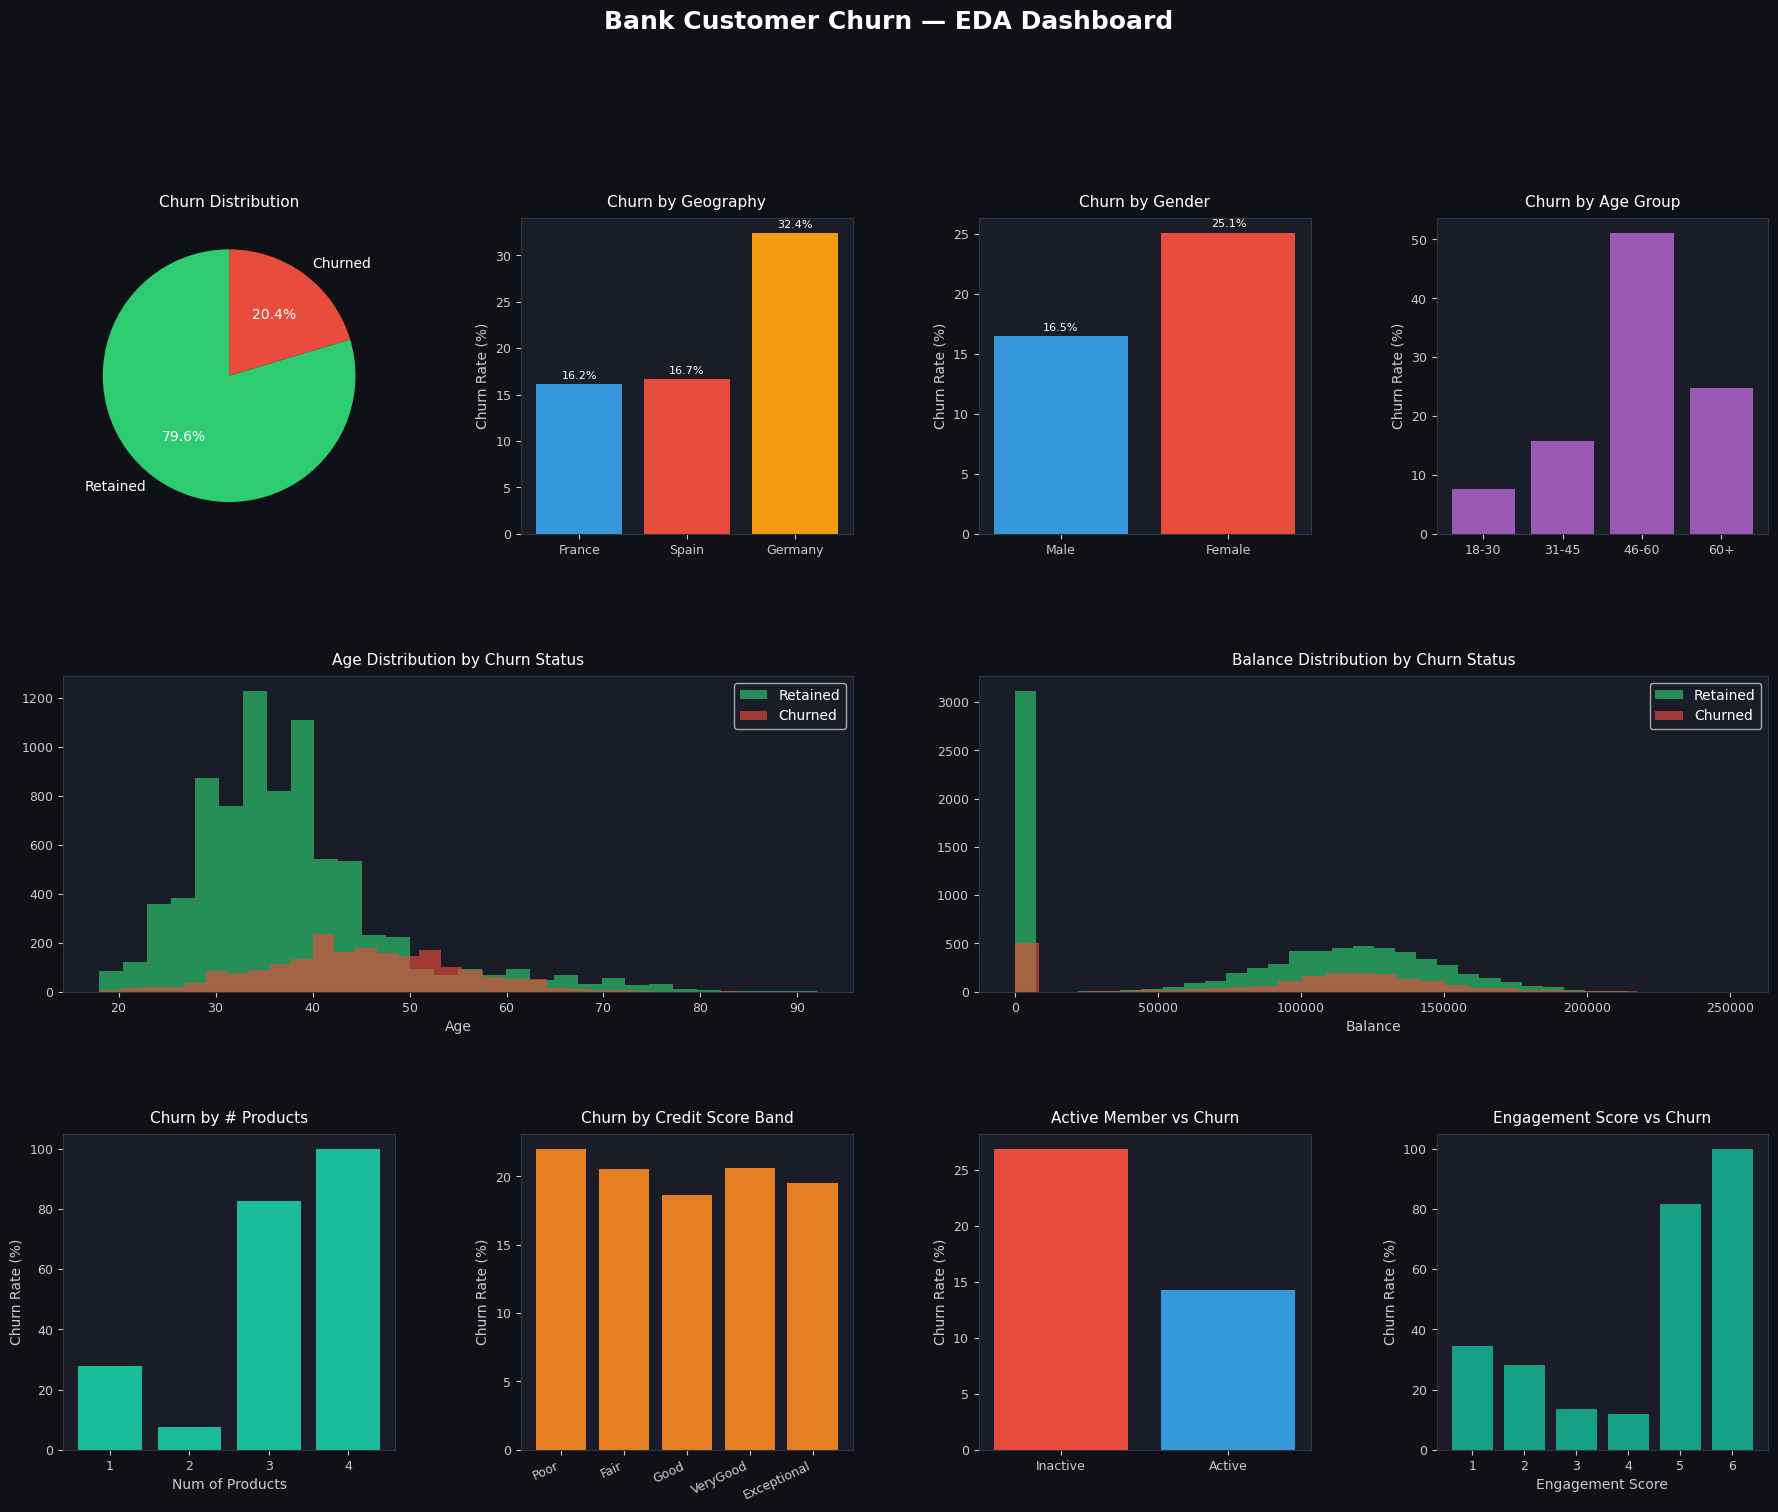

✅ Saved → outputs/eda_dashboard.png


In [9]:
# ── EDA Overview Dashboard ────────────────────────────────────
fig = plt.figure(figsize=(22, 16))
fig.patch.set_facecolor('#0f1117')
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.38)

# Churn pie
ax0 = fig.add_subplot(gs[0, 0])
dark_ax(ax0, 'Churn Distribution')
counts = df['Exited'].value_counts()
ax0.pie(counts, labels=['Retained','Churned'], colors=['#2ecc71', RED],
        autopct='%1.1f%%', startangle=90, textprops={'color':'white','fontsize':10})

# Geography churn rate
ax1 = fig.add_subplot(gs[0, 1])
dark_ax(ax1, 'Churn by Geography')
geo = df.groupby('Geography')['Exited'].mean().sort_values()
bars = ax1.bar(geo.index, geo.values * 100, color=[BLUE, RED, '#f39c12'])
ax1.set_ylabel('Churn Rate (%)')
for b in bars:
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
             f'{b.get_height():.1f}%', ha='center', va='bottom', color='white', fontsize=8)

# Gender churn rate
ax2 = fig.add_subplot(gs[0, 2])
dark_ax(ax2, 'Churn by Gender')
gen = df.groupby('Gender')['Exited'].mean().sort_values()
bars2 = ax2.bar(gen.index, gen.values * 100, color=[BLUE, RED])
ax2.set_ylabel('Churn Rate (%)')
for b in bars2:
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
             f'{b.get_height():.1f}%', ha='center', va='bottom', color='white', fontsize=8)

# Age group churn rate
ax3 = fig.add_subplot(gs[0, 3])
dark_ax(ax3, 'Churn by Age Group')
ag = df.groupby('AgeGroup', observed=True)['Exited'].mean()
ax3.bar(ag.index, ag.values * 100, color='#9b59b6')
ax3.set_ylabel('Churn Rate (%)')

# Age distribution
ax4 = fig.add_subplot(gs[1, 0:2])
dark_ax(ax4, 'Age Distribution by Churn Status')
for val, color, lbl in [(0,'#2ecc71','Retained'), (1,RED,'Churned')]:
    ax4.hist(df[df['Exited']==val]['Age'], bins=30, alpha=0.65,
             color=color, label=lbl, edgecolor='none')
ax4.legend(facecolor='#1a1d27', labelcolor='white')
ax4.set_xlabel('Age')

# Balance distribution
ax5 = fig.add_subplot(gs[1, 2:4])
dark_ax(ax5, 'Balance Distribution by Churn Status')
for val, color, lbl in [(0,'#2ecc71','Retained'), (1,RED,'Churned')]:
    ax5.hist(df[df['Exited']==val]['Balance'], bins=30, alpha=0.65,
             color=color, label=lbl, edgecolor='none')
ax5.legend(facecolor='#1a1d27', labelcolor='white')
ax5.set_xlabel('Balance')

# Products vs churn
ax6 = fig.add_subplot(gs[2, 0])
dark_ax(ax6, 'Churn by # Products')
pr = df.groupby('NumOfProducts')['Exited'].mean()
ax6.bar(pr.index, pr.values*100, color='#1abc9c')
ax6.set_xlabel('Num of Products'); ax6.set_ylabel('Churn Rate (%)')

# Credit band
ax7 = fig.add_subplot(gs[2, 1])
dark_ax(ax7, 'Churn by Credit Score Band')
cb = df.groupby('CreditScoreBand', observed=True)['Exited'].mean()
ax7.bar(cb.index, cb.values*100, color='#e67e22')
ax7.set_xticklabels(cb.index, rotation=25, ha='right')
ax7.set_ylabel('Churn Rate (%)')

# Active member
ax8 = fig.add_subplot(gs[2, 2])
dark_ax(ax8, 'Active Member vs Churn')
am = df.groupby('IsActiveMember')['Exited'].mean()
ax8.bar(['Inactive','Active'], am.values*100, color=[RED, BLUE])
ax8.set_ylabel('Churn Rate (%)')

# Engagement score
ax9 = fig.add_subplot(gs[2, 3])
dark_ax(ax9, 'Engagement Score vs Churn')
es = df.groupby('EngagementScore')['Exited'].mean()
ax9.bar(es.index, es.values*100, color='#16a085')
ax9.set_xlabel('Engagement Score'); ax9.set_ylabel('Churn Rate (%)')

fig.suptitle('Bank Customer Churn — EDA Dashboard',
             fontsize=18, color='white', y=1.01, fontweight='bold')
plt.savefig('outputs/eda_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("✅ Saved → outputs/eda_dashboard.png")

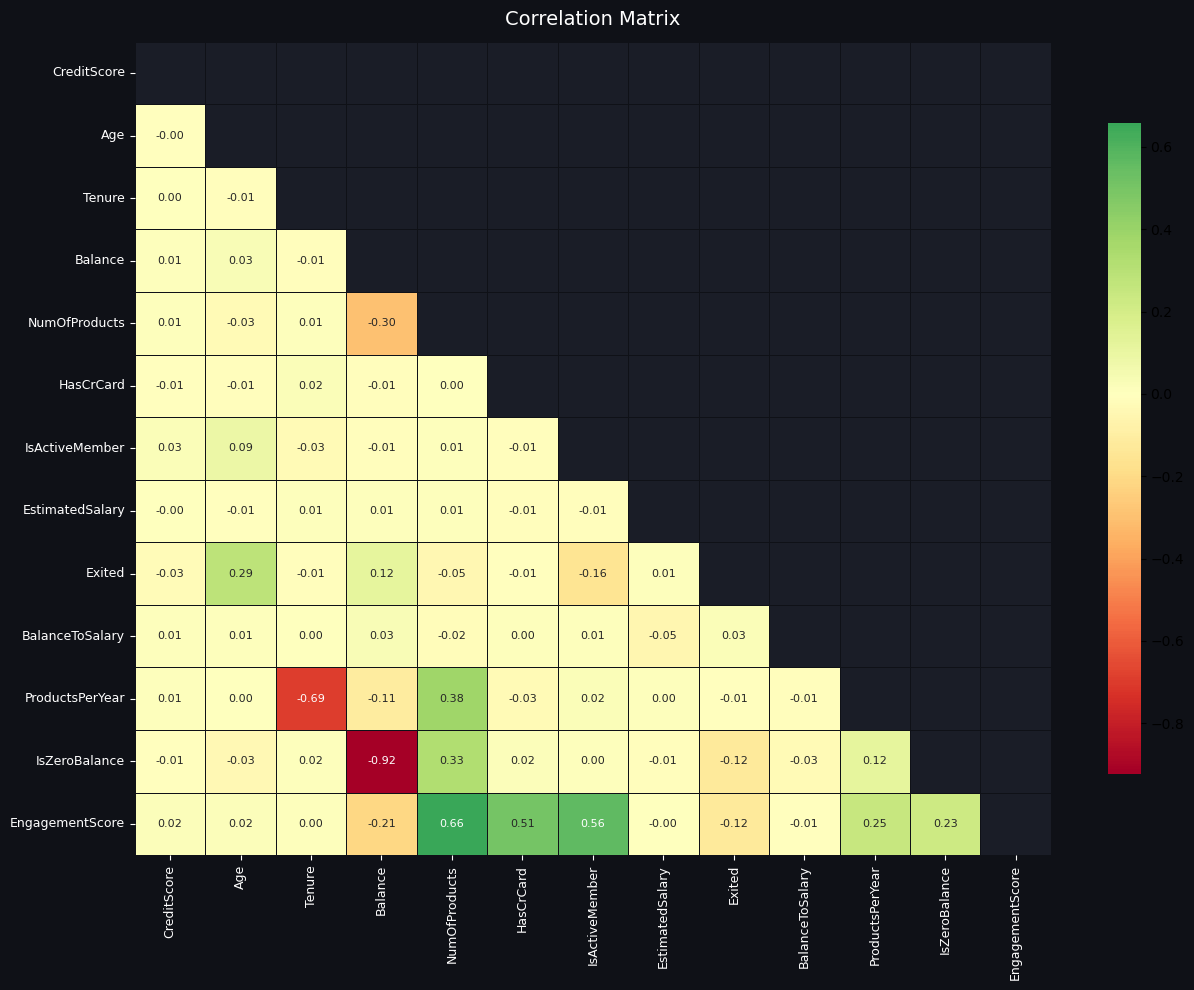

✅ Saved → outputs/correlation_heatmap.png


In [10]:
# ── Correlation Heatmap ───────────────────────────────────────
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig2, ax = plt.subplots(figsize=(13, 10))
fig2.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')
sns.heatmap(corr, mask=mask, cmap='RdYlGn', center=0, annot=True, fmt='.2f',
            ax=ax, linewidths=0.5, linecolor='#0f1117',
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 8})
ax.tick_params(colors='white', labelsize=9)
ax.set_title('Correlation Matrix', color='white', fontsize=14, pad=12)
plt.tight_layout()
plt.savefig('outputs/correlation_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("✅ Saved → outputs/correlation_heatmap.png")

In [11]:
# ── Key EDA Insights ─────────────────────────────────────────
insights = {
    'Overall Churn Rate':     f"{df['Exited'].mean():.2%}",
    'Germany Churn Rate':     f"{df[df['Geography']=='Germany']['Exited'].mean():.2%}",
    'Female Churn Rate':      f"{df[df['Gender']=='Female']['Exited'].mean():.2%}",
    'Male Churn Rate':        f"{df[df['Gender']=='Male']['Exited'].mean():.2%}",
    '3+ Products Churn Rate': f"{df[df['NumOfProducts']>=3]['Exited'].mean():.2%}",
    'Inactive Member Churn':  f"{df[df['IsActiveMember']==0]['Exited'].mean():.2%}",
    'Active Member Churn':    f"{df[df['IsActiveMember']==1]['Exited'].mean():.2%}",
    'Zero Balance Churn':     f"{df[df['IsZeroBalance']==1]['Exited'].mean():.2%}",
}

print("📊 KEY EDA INSIGHTS")
print("-" * 40)
for k, v in insights.items():
    print(f"  {k:<30} {v}")

📊 KEY EDA INSIGHTS
----------------------------------------
  Overall Churn Rate             20.37%
  Germany Churn Rate             32.44%
  Female Churn Rate              25.07%
  Male Churn Rate                16.46%
  3+ Products Churn Rate         85.89%
  Inactive Member Churn          26.85%
  Active Member Churn            14.27%
  Zero Balance Churn             13.82%


## 6. Machine Learning Pipeline

In [12]:
# ── Encode categoricals ──────────────────────────────────────
ml_df  = df.copy()
le_geo = LabelEncoder(); ml_df['Geography'] = le_geo.fit_transform(ml_df['Geography'])
le_gen = LabelEncoder(); ml_df['Gender']    = le_gen.fit_transform(ml_df['Gender'])
ml_df  = ml_df.drop(columns=['AgeGroup', 'CreditScoreBand'])

X = ml_df.drop('Exited', axis=1)
y = ml_df['Exited']

print("Feature matrix shape:", X.shape)
print("Target distribution:\n", y.value_counts())
print("\nFeatures:", X.columns.tolist())

Feature matrix shape: (10000, 14)
Target distribution:
 Exited
0    7963
1    2037
Name: count, dtype: int64

Features: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'BalanceToSalary', 'ProductsPerYear', 'IsZeroBalance', 'EngagementScore']


In [13]:
# ── Train / Test Split & Scaling ─────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler   = StandardScaler()
Xtr_sc   = scaler.fit_transform(X_train)
Xte_sc   = scaler.transform(X_test)
Xall_sc  = scaler.transform(X)

print(f"Training set : {X_train.shape}")
print(f"Test set     : {X_test.shape}")
print(f"Churn in test: {y_test.mean():.2%}")

Training set : (8000, 14)
Test set     : (2000, 14)
Churn in test: 20.35%


In [14]:
# ── Train 3 Models ───────────────────────────────────────────
MODELS = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        max_depth=8, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42),
}

results = {}
for name, model in MODELS.items():
    use_sc = 'Logistic' in name
    Xtr  = Xtr_sc  if use_sc else X_train.values
    Xte  = Xte_sc  if use_sc else X_test.values
    Xall = Xall_sc if use_sc else X.values

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    cv_auc = cross_val_score(model, Xall, y, cv=5, scoring='roc_auc').mean()

    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
        'auc': auc, 'cv_auc': cv_auc, 'use_sc': use_sc
    }
    print(f"\n── {name}")
    print(f"   Test AUC : {auc:.4f}   CV-AUC : {cv_auc:.4f}")

best_name = max(results, key=lambda n: results[n]['auc'])
best = results[best_name]
print(f"\n🏆 Best model: {best_name}  (AUC = {best['auc']:.4f})")


── Logistic Regression
   Test AUC : 0.7728   CV-AUC : 0.7594

── Random Forest
   Test AUC : 0.8502   CV-AUC : 0.8540

── Gradient Boosting
   Test AUC : 0.8615   CV-AUC : 0.8611

🏆 Best model: Gradient Boosting  (AUC = 0.8615)


In [15]:
# ── Classification Report (Best Model) ───────────────────────
print(f"Classification Report — {best_name}\n")
print(classification_report(y_test, best['y_pred'],
                             target_names=['Retained', 'Churned'], digits=3))

Classification Report — Gradient Boosting

              precision    recall  f1-score   support

    Retained      0.877     0.964     0.918      1593
     Churned      0.768     0.472     0.584       407

    accuracy                          0.864      2000
   macro avg      0.823     0.718     0.751      2000
weighted avg      0.855     0.864     0.850      2000



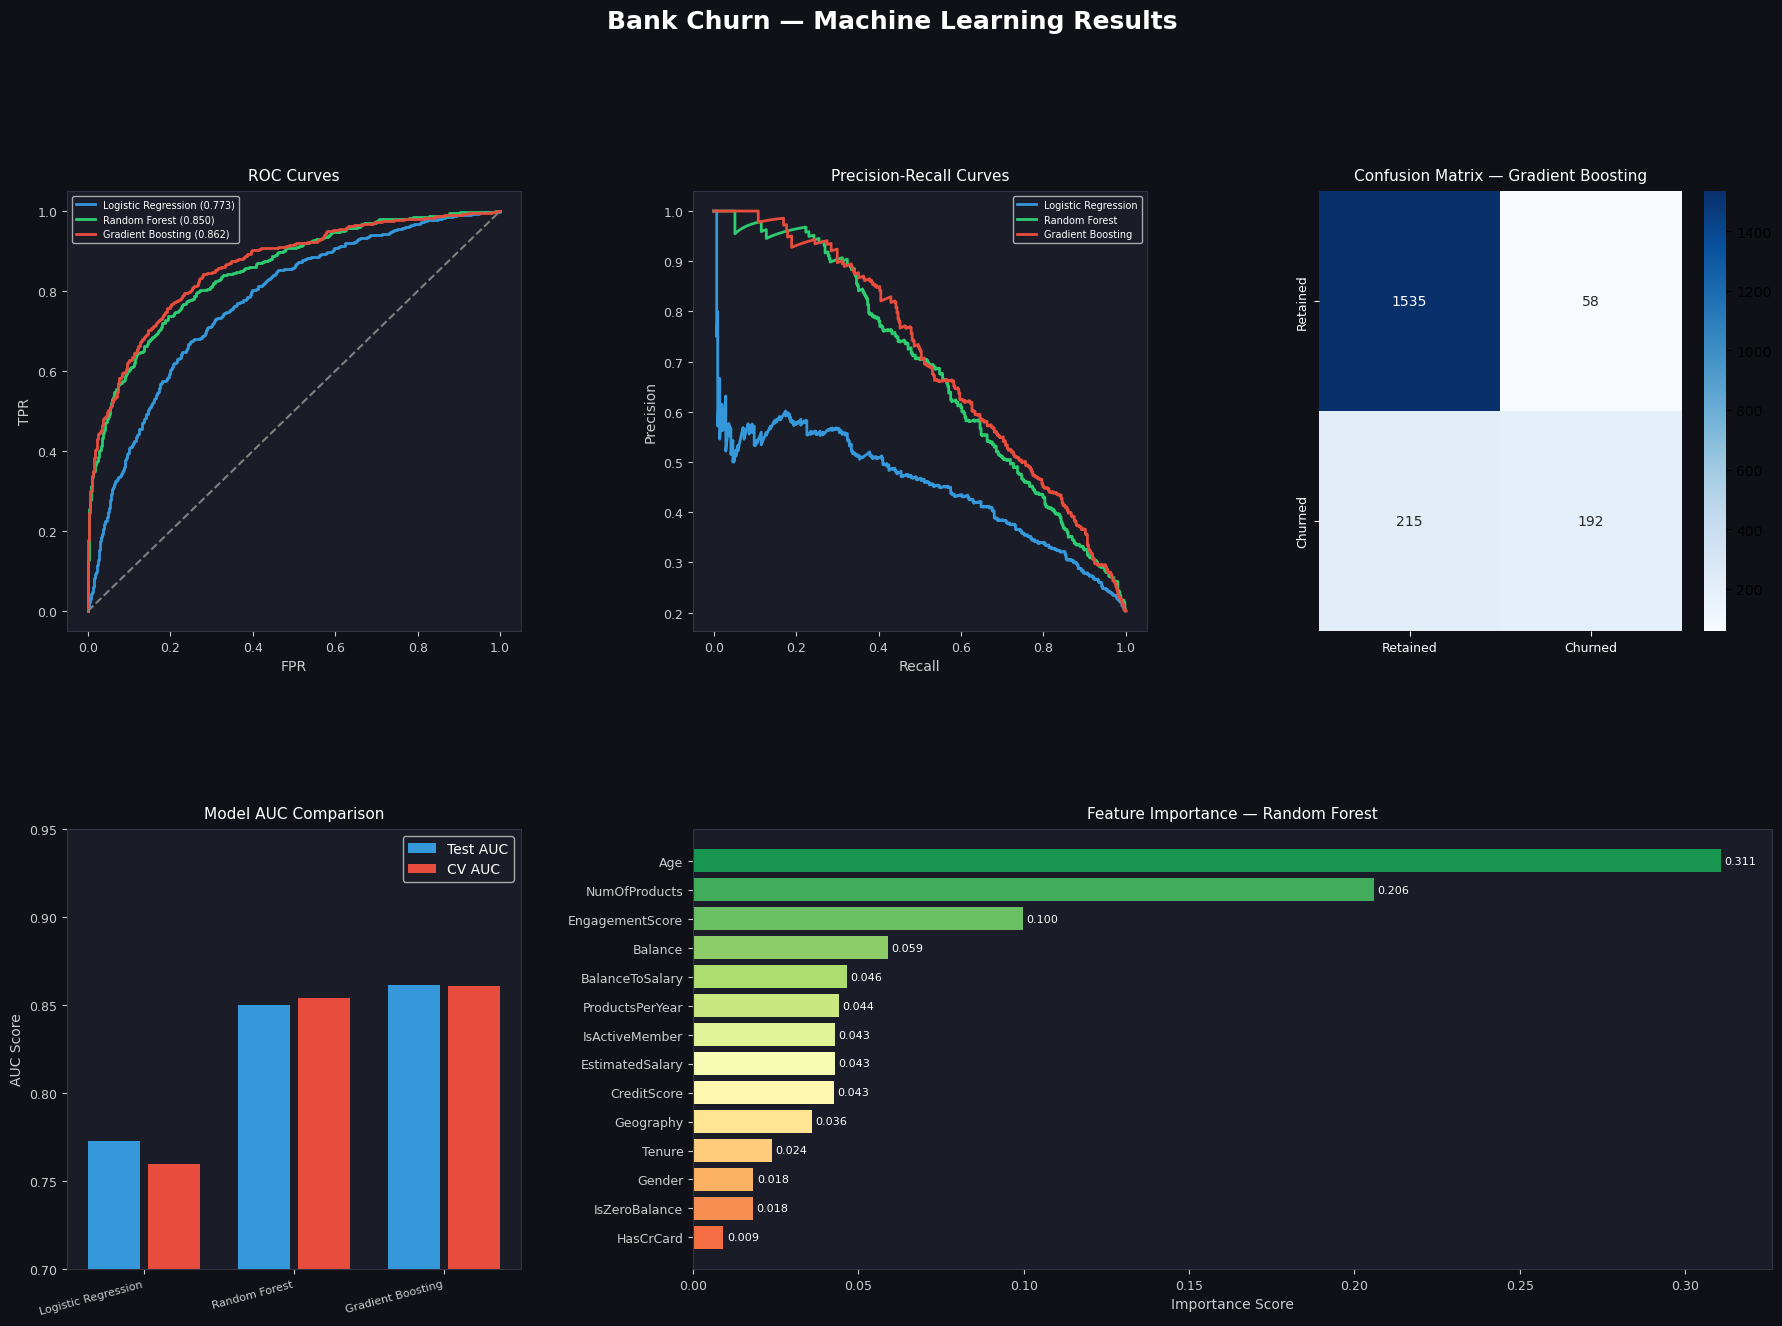

✅ Saved → outputs/ml_results.png


In [16]:
# ── ML Visualisations ────────────────────────────────────────
fig3 = plt.figure(figsize=(22, 14))
fig3.patch.set_facecolor('#0f1117')
gs3  = gridspec.GridSpec(2, 3, figure=fig3, hspace=0.45, wspace=0.38)
colors_roc = ['#3498db', '#2ecc71', '#e74c3c']

# ROC Curves
ax_roc = fig3.add_subplot(gs3[0, 0])
dark_ax(ax_roc, 'ROC Curves')
for (nm, res), col in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax_roc.plot(fpr, tpr, label=f"{nm} ({res['auc']:.3f})", color=col, lw=2)
ax_roc.plot([0,1],[0,1],'--', color='gray')
ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
ax_roc.legend(facecolor='#1a1d27', labelcolor='white', fontsize=7)

# Precision-Recall
ax_pr = fig3.add_subplot(gs3[0, 1])
dark_ax(ax_pr, 'Precision-Recall Curves')
for (nm, res), col in zip(results.items(), colors_roc):
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])
    ax_pr.plot(rec, prec, label=nm, color=col, lw=2)
ax_pr.set_xlabel('Recall'); ax_pr.set_ylabel('Precision')
ax_pr.legend(facecolor='#1a1d27', labelcolor='white', fontsize=7)

# Confusion Matrix
ax_cm = fig3.add_subplot(gs3[0, 2])
dark_ax(ax_cm, f'Confusion Matrix — {best_name}')
cm = confusion_matrix(y_test, best['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm,
            xticklabels=['Retained','Churned'],
            yticklabels=['Retained','Churned'])
ax_cm.tick_params(colors='white')

# AUC comparison
ax_auc = fig3.add_subplot(gs3[1, 0])
dark_ax(ax_auc, 'Model AUC Comparison')
names_ = list(results.keys())
aucs_  = [results[n]['auc']    for n in names_]
cvs_   = [results[n]['cv_auc'] for n in names_]
xpos   = np.arange(len(names_))
ax_auc.bar(xpos-0.2, aucs_, 0.35, label='Test AUC', color='#3498db')
ax_auc.bar(xpos+0.2, cvs_,  0.35, label='CV AUC',   color='#e74c3c')
ax_auc.set_xticks(xpos)
ax_auc.set_xticklabels(names_, rotation=15, ha='right', fontsize=8)
ax_auc.set_ylim(0.7, 0.95)
ax_auc.legend(facecolor='#1a1d27', labelcolor='white')
ax_auc.set_ylabel('AUC Score')

# Feature Importance (Random Forest)
rf       = results['Random Forest']['model']
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
ax_fi    = fig3.add_subplot(gs3[1, 1:])
dark_ax(ax_fi, 'Feature Importance — Random Forest')
cmap_fi  = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_imp)))
ax_fi.barh(feat_imp.index, feat_imp.values, color=cmap_fi)
ax_fi.set_xlabel('Importance Score')
for i, v in enumerate(feat_imp.values):
    ax_fi.text(v+0.001, i, f'{v:.3f}', va='center', color='white', fontsize=8)

fig3.suptitle('Bank Churn — Machine Learning Results',
              fontsize=18, color='white', y=1.01, fontweight='bold')
plt.savefig('outputs/ml_results.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("✅ Saved → outputs/ml_results.png")

## 7. Export Enriched CSV for Power BI

In [17]:
# Generate churn probabilities on the full dataset
X_all     = ml_df.drop('Exited', axis=1)
proba_all = (best['model'].predict_proba(Xall_sc)[:, 1]
             if best['use_sc']
             else best['model'].predict_proba(X_all.values)[:, 1])

# Attach predictions to original dataframe
export_df = df.copy()
export_df['ChurnProbability'] = np.round(proba_all, 4)
export_df['ChurnRiskSegment'] = pd.cut(
    proba_all, bins=[0, 0.3, 0.6, 1.0],
    labels=['Low', 'Medium', 'High']
)
export_df['PredictedChurn'] = (proba_all >= 0.5).astype(int)

CSV_PATH = 'outputs/Bank_Churn_Enriched.csv'
export_df.to_csv(CSV_PATH, index=False)

print(f"✅ Saved → {CSV_PATH}")
print(f"   Shape  : {export_df.shape}")
print(f"\nRisk Segment Breakdown:")
print(export_df['ChurnRiskSegment'].value_counts().to_string())
print(f"\nSample predictions:")
export_df[['Age','Geography','Gender','Balance','ChurnProbability',
           'ChurnRiskSegment','PredictedChurn']].head(10)

✅ Saved → outputs/Bank_Churn_Enriched.csv
   Shape  : (10000, 20)

Risk Segment Breakdown:
ChurnRiskSegment
Low       7826
Medium    1127
High      1047

Sample predictions:


,Age,Geography,Gender,Balance,ChurnProbability,ChurnRiskSegment,PredictedChurn
0,42,France,Female,0.00,0.2387,Low,0
1,41,Spain,Female,83807.86,0.2831,Low,0
2,42,France,Female,159660.80,0.9738,High,1
3,39,France,Female,0.00,0.0541,Low,0
4,43,Spain,Female,125510.82,0.0370,Low,0
5,44,Spain,Male,113755.78,0.1473,Low,0
6,50,France,Male,0.00,0.0544,Low,0
7,29,Germany,Female,115046.74,0.9801,High,1
8,44,France,Male,142051.07,0.0952,Low,0
9,27,France,Male,134603.88,0.0446,Low,0


## 8. Summary & Key Insights

In [18]:
print("=" * 55)
print("  BANK CHURN ANALYSIS — SUMMARY")
print("=" * 55)

print(f"\n📊 DATASET")
print(f"   Records         : {len(df):,}")
print(f"   Features used   : {X.shape[1]}")
print(f"   Overall churn   : {df['Exited'].mean():.2%}")

print(f"\n🔍 TOP EDA FINDINGS")
print(f"   Germany churn   : {df[df['Geography']=='Germany']['Exited'].mean():.2%} (highest geography)")
print(f"   Female churn    : {df[df['Gender']=='Female']['Exited'].mean():.2%} vs Male {df[df['Gender']=='Male']['Exited'].mean():.2%}")
print(f"   Age 46-60       : highest churn age group")
print(f"   3+ products     : {df[df['NumOfProducts']>=3]['Exited'].mean():.2%} churn rate (danger zone)")
print(f"   Inactive churn  : {df[df['IsActiveMember']==0]['Exited'].mean():.2%} vs Active {df[df['IsActiveMember']==1]['Exited'].mean():.2%}")

print(f"\n🤖 MODEL RESULTS")
for name, res in results.items():
    marker = ' 🏆' if name == best_name else ''
    print(f"   {name:<25} AUC={res['auc']:.4f}  CV={res['cv_auc']:.4f}{marker}")

print(f"\n📁 OUTPUT FILES")
print(f"   outputs/eda_dashboard.png")
print(f"   outputs/correlation_heatmap.png")
print(f"   outputs/ml_results.png")
print(f"   outputs/Bank_Churn_Enriched.csv  ← load in Power BI")
print("=" * 55)

  BANK CHURN ANALYSIS — SUMMARY

📊 DATASET
   Records         : 10,000
   Features used   : 14
   Overall churn   : 20.37%

🔍 TOP EDA FINDINGS
   Germany churn   : 32.44% (highest geography)
   Female churn    : 25.07% vs Male 16.46%
   Age 46-60       : highest churn age group
   3+ products     : 85.89% churn rate (danger zone)
   Inactive churn  : 26.85% vs Active 14.27%

🤖 MODEL RESULTS
   Logistic Regression       AUC=0.7728  CV=0.7594
   Random Forest             AUC=0.8502  CV=0.8540
   Gradient Boosting         AUC=0.8615  CV=0.8611 🏆

📁 OUTPUT FILES
   outputs/eda_dashboard.png
   outputs/correlation_heatmap.png
   outputs/ml_results.png
   outputs/Bank_Churn_Enriched.csv  ← load in Power BI
